In [1]:
######################################################################
## 04_ANALYSIS: Calculating CpG oe ratio plots in R
######################################################################

## This should be done after the python steps have been completed

In [2]:
######################################################################
## BLOCK 0. Project setup: folders (relative, silent)
######################################################################

suppressPackageStartupMessages(library(here))

# Create expected project directories (relative to repo root)
dir.create(here("data"), recursive = TRUE, showWarnings = FALSE)
dir.create(here("outputs", "figures"), recursive = TRUE, showWarnings = FALSE)
dir.create(here("outputs", "session"), recursive = TRUE, showWarnings = FALSE)

In [3]:
######################################################################
## BLOCK 1. Setup & Load Merged Files
######################################################################

library(ggplot2)
library(viridis)
library(dplyr)
library(readr)
library(Cairo)
library(here)
library(tibble)

# Load data from project-local data/
df_gene <- read_tsv(here("data", "cpg_methylation_filtered.tsv"), show_col_types = FALSE) %>%
  mutate(region = "Gene Body")

df_prom <- read_tsv(here("data", "promoter_cpg_methylation_filtered.tsv"), show_col_types = FALSE) %>%
  mutate(region = "Promoter")

# Combine and transform
combined <- bind_rows(df_gene, df_prom) %>%
  mutate(
    log_meth = log10(avg_methylation + 1e-6),
    region = factor(region, levels = c("Gene Body", "Promoter"))
  )

# Spearman correlations (match what you report)
rho_gene <- cor(df_gene$cpg_oe, log10(df_gene$avg_methylation + 1e-6), method = "spearman", use = "complete.obs")
rho_prom <- cor(df_prom$cpg_oe, log10(df_prom$avg_methylation + 1e-6), method = "spearman", use = "complete.obs")

# Rho label positions (inside panel, top-right-ish)
rho_df <- tibble(
  region   = factor(c("Gene Body", "Promoter"), levels = c("Gene Body", "Promoter")),
  cpg_oe   = c(1.18, 1.18),
  log_meth = c(1.55, 1.55),
  rho_text = c(
    paste0("rho == ", round(rho_gene, 3)),
    paste0("rho == ", round(rho_prom, 3))
  )
)

Loading required package: viridisLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `plot.tag.padding` theme element is not defined in the element hierarchy.”


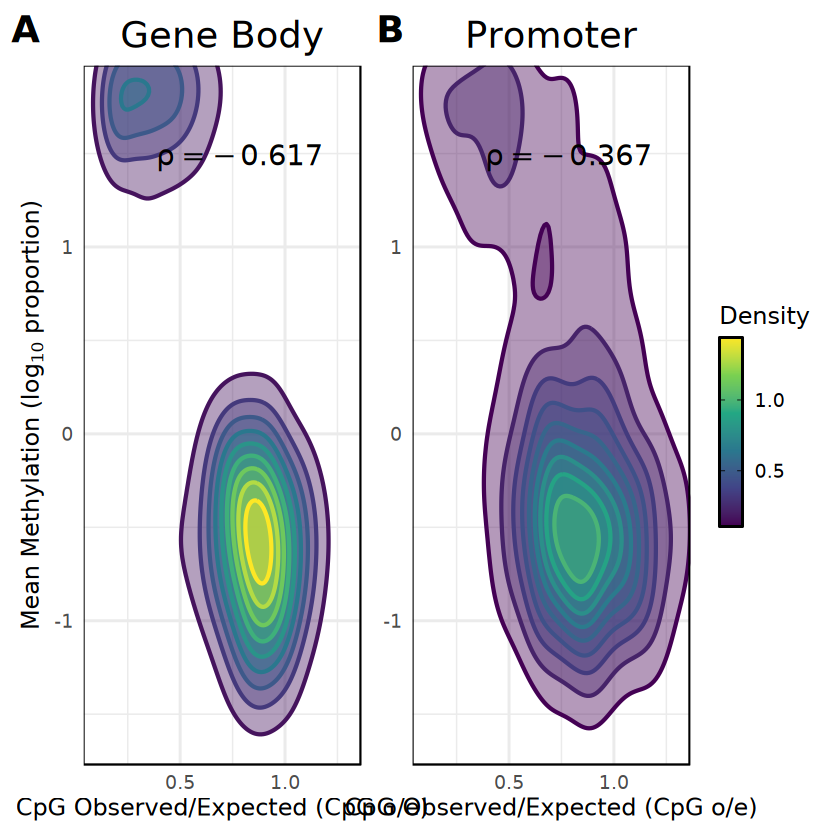

In [4]:
######################################################################
## BLOCK 2. Figure S1
######################################################################

library(patchwork)

xlim_use <- c(0.1, 1.3)
ylim_use <- c(-1.6, 1.8)

# Split data explicitly (so density is computed per panel, but we still harmonize scales)
gene_dat <- combined %>% filter(region == "Gene Body")
prom_dat <- combined %>% filter(region == "Promoter")

# Helper: get the range of computed "level" from stat_density_2d
get_level_range <- function(df) {
  tmp <- ggplot(df, aes(cpg_oe, log_meth)) +
    stat_density_2d(
      aes(fill = after_stat(level)),
      geom = "polygon",
      contour = TRUE,
      n = 200,
      bins = 10
    ) +
    coord_cartesian(xlim = xlim_use, ylim = ylim_use)

  b <- ggplot_build(tmp)

  # layer 1 is the polygon density
  lv <- b$data[[1]]$level
  range(lv, na.rm = TRUE)
}

rng_gene <- get_level_range(gene_dat)
rng_prom <- get_level_range(prom_dat)

level_limits <- range(c(rng_gene, rng_prom), na.rm = TRUE)

make_panel <- function(df, panel_title) {
  ggplot(df, aes(x = cpg_oe, y = log_meth)) +
    stat_density_2d(
      aes(fill = after_stat(level)),
      geom    = "polygon",
      contour = TRUE,
      n       = 200,
      bins    = 10,
      alpha   = 0.40,
      color   = NA
    ) +
    stat_density_2d(
      aes(color = after_stat(level)),
      n    = 200,
      bins = 10,
      linewidth = 0.9
    ) +
    geom_text(
      data = rho_df %>% filter(region == panel_title),
      aes(x = cpg_oe, y = log_meth, label = rho_text),
      inherit.aes = FALSE,
      parse = TRUE,
      hjust = 1, vjust = 1,
      size = 6, fontface = "italic", color = "black"
    ) +
    coord_cartesian(xlim = xlim_use, ylim = ylim_use) +
    scale_fill_viridis_c(
      option = "D",
      name   = "Density",
      limits = level_limits
    ) +
    scale_color_viridis_c(
      option = "D",
      limits = level_limits,
      guide  = "none"
    ) +
    guides(fill = guide_colorbar(
      ticks = TRUE,
      ticks.colour = "black",
      barwidth  = grid::unit(5,  "mm"),
      barheight = grid::unit(40, "mm"),
      frame.colour = "black"
    )) +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(size = 22, hjust = 0.5),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5),
      legend.position = "right"
    ) +
    labs(
      title = panel_title,
      x = "CpG Observed/Expected (CpG o/e)",
      y = expression("Mean Methylation ("*log[10]*" proportion)")
    )
}

pA <- make_panel(gene_dat, "Gene Body")
pB <- make_panel(prom_dat, "Promoter") +
  theme(axis.title.y = element_blank())

# Combine; collect legend; add A/B tags positioned in the header area
p_fig1 <- (pA | pB) +
  plot_layout(guides = "collect") +
  plot_annotation(tag_levels = list(c("A", "B"))) &
  theme(
    plot.tag = element_text(size = 22, face = "bold"),
    # push tag into the top-left “header” region, not inside the plot panel
    plot.tag.position = c(0.015, 0.99),
    plot.tag.padding = grid::unit(c(3, 3, 3, 3), "mm")
  )

ggsave(
  filename = here("outputs", "figures", "FigS1.pdf"),
  plot     = p_fig1,
  device   = grDevices::cairo_pdf,
  width    = 10, height = 5, units = "in",
  bg       = "white"
)

p_fig1  # display inline


In [5]:
######################################################################
## Reproducibility: session + package versions (printed)
######################################################################

cat("Date:", as.character(Sys.Date()), "\n")
cat("R version:", R.version.string, "\n")
cat("Platform:", paste(R.version$platform, R.version$arch, sep = " / "), "\n")
cat("OS:", Sys.info()[["sysname"]], Sys.info()[["release"]], "\n\n")

pkgs <- c("ggplot2","dplyr","readr","viridis","viridisLite","Cairo","here","patchwork","grid")

cat("Key package versions:\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), as.character(packageVersion(p))))
  } else {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), "not installed"))
  }
}


Date: 2026-07-30 
R version: R version 4.3.3 (2024-02-29) 
Platform: x86_64-conda-linux-gnu / x86_64 
OS: Linux 5.15.0-185-generic 

Key package versions:
  ggplot2:       3.5.2
  dplyr:         1.1.4
  readr:         2.1.5
  viridis:       0.6.5
  viridisLite:   0.4.2
  Cairo:         1.6.5
  here:          1.0.2
  patchwork:     1.3.1
  grid:          4.3.3
